In [2]:
import numpy as np
from numpy.fft import fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
import h5py

In [11]:
def psf_high_NA_vector(N_pupil=256, pad_factor=8,
                       wavelength=0.580,        # µm
                       NA=1.40, n=1.5,
                       pol='circ',
                       A_def=0.0, A_ast=0.0, A_ast_y=0.0,
                       A_coma_x=0.0, A_coma_y=0.0,
                       A_trefoil_x=0.0, A_trefoil_y=0.0, A_sph=0.0):
    """
    Vectorial in-focus PSF via Debye–Wolf integral with Zernike aberrations.

    Parameters
    ----------
    N_pupil    : samples across aperture diameter
    pad_factor : zero-padding factor for image plane sampling
    wavelength : wavelength [µm]
    NA, n      : numerical aperture, immersion index
    pol        : 'x', 'y', or 'lin45' input polarization
    Aberration coeffs in waves at the pupil edge.
    
    Returns
    -------
    psf : (M,M) normalised intensity
    x,y : coordinates in µm
    """
    k = 2 * np.pi / wavelength
    M  = N_pupil * pad_factor
    P  = np.zeros((M, M), dtype=complex)

    mid    = M // 2
    half   = N_pupil // 2
    sl     = slice(mid - half, mid + half)
    u,v    = np.mgrid[-1:1:N_pupil*1j, -1:1:N_pupil*1j]
    rho    = np.sqrt(u**2 + v**2)
    theta  = np.arctan2(v, u)
    mask   = rho <= 1

    # Map pupil radius rho -> sinθ
    sin_t_max = NA / n
    sin_t     = rho * sin_t_max
    sin_t[~mask] = 0.0
    cos_t     = np.sqrt(1 - sin_t**2)

    # Zernike polynomials (unnormalised)
    Z20 = 2*rho**2 - 1
    Z22 = rho**2 * np.cos(2*theta)
    Z2m2 = rho**2 * np.sin(2*theta)
    Z31 = (3*rho**3 - 2*rho) * np.cos(theta)
    Z3m1 = (3*rho**3 - 2*rho) * np.sin(theta)
    Z33 = rho**3 * np.cos(3*theta)
    Z3m3 = rho**3 * np.sin(3*theta)
    Z40 = 6*rho**4 - 6*rho**2 + 1

    # Normalize Zernikes over pupil
    for Z in (Z20, Z22, Z2m2, Z31, Z3m1, Z33, Z3m3, Z40):
        Z /= np.sqrt(np.mean(Z[mask]**2))

    phase = 2 * np.pi * (
        A_def       * Z20 +
        A_ast       * Z22 +
        A_ast_y     * Z2m2 +
        A_coma_x    * Z31 +
        A_coma_y    * Z3m1 +
        A_trefoil_x * Z33 +
        A_trefoil_y * Z3m3 +
        A_sph       * Z40
    )

    # Vectorial pupil field (Richards–Wolf)
    if pol.lower() == 'x':
        Ex_pupil = cos_t + (1 - cos_t) * np.cos(2*theta)
        Ey_pupil = (1 - cos_t) * np.sin(2*theta)
    elif pol.lower() == 'y':
        Ex_pupil = (1 - cos_t) * np.sin(2*theta)
        Ey_pupil = cos_t - (1 - cos_t) * np.cos(2*theta)
    elif pol.lower() == 'lin45':
        Ex_lin = cos_t + (1 - cos_t) * np.cos(2*theta)
        Ey_lin = (1 - cos_t) * np.sin(2*theta)
        Ex_pupil = (Ex_lin + Ey_lin) / np.sqrt(2)
        Ey_pupil = (Ey_lin + (cos_t - (1 - cos_t) * np.cos(2*theta))) / np.sqrt(2)
    elif pol.lower() == 'circ':
        # Circular polarization = (x-pol + i y-pol) / sqrt(2)
        Ex_x = cos_t + (1 - cos_t) * np.cos(2*theta)
        Ey_x = (1 - cos_t) * np.sin(2*theta)
        Ex_y = (1 - cos_t) * np.sin(2*theta)
        Ey_y = cos_t - (1 - cos_t) * np.cos(2*theta)
        Ex_pupil = (Ex_x + 1j * Ex_y) / np.sqrt(2)
        Ey_pupil = (Ey_x + 1j * Ey_y) / np.sqrt(2)
    else:
        raise ValueError("pol must be 'x', 'y', 'lin45', or 'circ'")

    # Apodisation = sqrt(cosθ) from Debye–Wolf theory
    apod = np.sqrt(cos_t) * mask

    # Apply phase and apodisation
    Px = apod * Ex_pupil * np.exp(1j*phase)
    Py = apod * Ey_pupil * np.exp(1j*phase)

    # Insert into padded array
    Px_full = np.zeros_like(P)
    Py_full = np.zeros_like(P)
    Px_full[sl, sl] = Px
    Py_full[sl, sl] = Py

    # FFT to image plane
    fx = fftshift(ifft2(ifftshift(Px_full)))
    fy = fftshift(ifft2(ifftshift(Py_full)))

    # Intensity from vector components
    psf = np.abs(fx)**2 + np.abs(fy)**2
    psf /= psf.sum()

    # Coordinates in µm
    df = (NA / wavelength) / (N_pupil / 2)   # cycles/µm
    dx = 1 / (M * df)                        # µm per pixel
    coords = (np.arange(M) - mid) * dx

    return psf, coords, coords

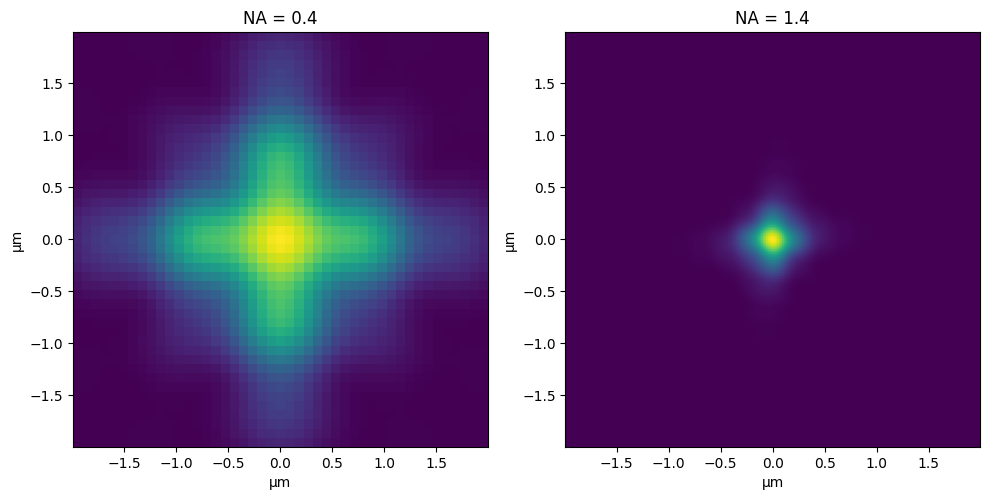

In [12]:
# Compute PSFs
psf_low, x_low, y_low = psf_high_NA_vector(NA=0.4, A_ast=0.2)
psf_high, x_high, y_high = psf_high_NA_vector(NA=1.4, A_ast=0.2)

# Define zoom range in µm
zoom_range = 2.0  # ± range from center

ix_low = np.where((x_low >= -zoom_range) & (x_low <= zoom_range))[0]
iy_low = np.where((y_low >= -zoom_range) & (y_low <= zoom_range))[0]
ix_high = np.where((x_high >= -zoom_range) & (x_high <= zoom_range))[0]
iy_high = np.where((y_high >= -zoom_range) & (y_high <= zoom_range))[0]

# Plot zoomed PSFs
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

im1 = axs[0].imshow(psf_low[np.ix_(iy_low, ix_low)],
                    extent=[x_low[ix_low[0]], x_low[ix_low[-1]],
                            y_low[iy_low[0]], y_low[iy_low[-1]]],
                    origin='lower')
axs[0].set_title("NA = 0.4")
axs[0].set_xlabel("µm")
axs[0].set_ylabel("µm")

im2 = axs[1].imshow(psf_high[np.ix_(iy_high, ix_high)],
                    extent=[x_high[ix_high[0]], x_high[ix_high[-1]],
                            y_high[iy_high[0]], y_high[iy_high[-1]]],
                    origin='lower')
axs[1].set_title("NA = 1.4")
axs[1].set_xlabel("µm")
axs[1].set_ylabel("µm")

plt.tight_layout()
plt.show()

In [13]:
import cv2

def scaled_psf_vector(px_size_um: float,
                      NA: float = 1.4,
                      n: float = 1.5,
                      wavelength: float = 0.550,
                      N_pupil: int = 256,
                      pad_factor: int = 8,
                      **A_kwargs) -> np.ndarray:
    """
    Generate a 50x50 PSF from psf_high_NA_vector with given real pixel size.

    Parameters
    ----------
    px_size_um : float
        Pixel size in µm for the final 50x50 image.
    NA, n : float
        Numerical aperture and refractive index.
    wavelength : float
        Wavelength in µm.
    N_pupil, pad_factor : int
        Sampling settings for PSF simulation.
    **A_kwargs : dict
        Aberration coefficients for psf_high_NA_vector.

    Returns
    -------
    np.ndarray : 50x50 PSF normalized to sum = 1.
    """
    # Generate high-resolution PSF
    hires, x, y = psf_high_NA_vector(N_pupil=N_pupil,
                                     pad_factor=pad_factor,
                                     wavelength=wavelength,
                                     NA=NA, n=n,
                                     **A_kwargs)

    dx = x[1] - x[0]  # µm per pixel in simulation
    halfwidth_um = (50 / 2) * px_size_um  # physical half-width for crop
    halfwidth_steps = int(round(halfwidth_um / dx))

    mid = hires.shape[0] // 2
    cropped = hires[
        mid - halfwidth_steps : mid + halfwidth_steps,
        mid - halfwidth_steps : mid + halfwidth_steps
    ]

    # Resize to exactly 50×50 pixels
    scaled = cv2.resize(cropped, (50, 50), interpolation=cv2.INTER_CUBIC)

    # Normalize intensity
    return scaled / scaled.sum()

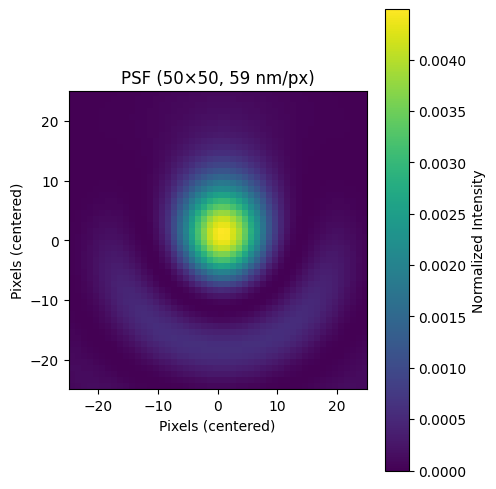

In [14]:
psf_59nm = scaled_psf_vector(px_size_um=0.059, NA=0.4, n=1.5, A_ast=0.0, A_coma_x=0.1)

# Plot with pixel coordinates
plt.figure(figsize=(5,5))
plt.imshow(psf_59nm,
           extent=[-25, 25, -25, 25],  # pixels from center
           origin='lower')
plt.colorbar(label='Normalized Intensity')
plt.title("PSF (50×50, 59 nm/px)")
plt.xlabel("Pixels (centered)")
plt.ylabel("Pixels (centered)")
plt.tight_layout()
plt.show()

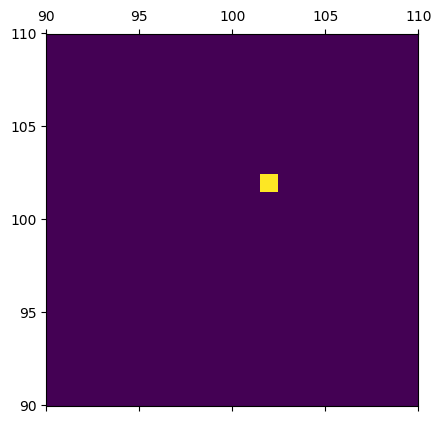

In [15]:
plt.matshow(image)
plt.xlim(100-10,100+10)
plt.ylim(100-10,100+10)
plt.show()

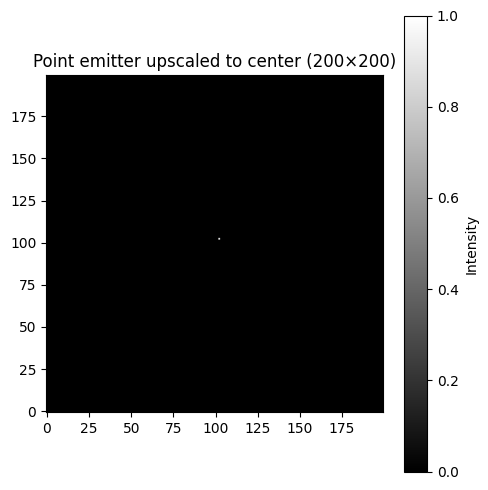

In [16]:
base_size = 50
scale = 4
up_size = base_size * scale

# Coordinates of emitter in 50x50 (center)
x_base, y_base = base_size / 2, base_size / 2
intensity = 1.0

# Upscale coordinates with shift to keep center aligned
shift = (scale - 1) / 2
x_up = x_base * scale + shift
y_up = y_base * scale + shift

# Create upscaled image and place emitter
image = np.zeros((up_size, up_size), dtype=np.float32)
image[int(round(y_up)), int(round(x_up))] = intensity

# Display
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray', origin='lower')
plt.title(f"Point emitter upscaled to center ({up_size}×{up_size})")
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()

# Save to HDF5
with h5py.File("point_emitter_center.h5", "w") as f:
    f.create_dataset("image", data=image)
    f.create_dataset("xyi", data=np.array([x_up, y_up, intensity]))
    f.attrs["description"] = f"{up_size}×{up_size} image with a single emitter upscaled from 50×50"
    f.attrs["scale"] = scale
    f.attrs["original_center"] = (x_base, y_base)
    f.attrs["upscaled_position"] = (x_up, y_up)

In [17]:
num_psfs = 30
A_ast_values = np.linspace(0.0, 0.3, num_psfs)

img_size = 50

psf_stack = np.zeros((num_psfs, img_size, img_size), dtype=np.float32)

for i, A_ast in enumerate(A_ast_values):
    psf = scaled_psf_vector(px_size_um=0.059, NA=1.4, n=1.5, A_ast=A_ast)
    psf_stack[i] = psf  # unblurred
    #psf_stack[i] = ndi.gaussian_filter(psf, 1)

# Save to HDF5
with h5py.File('psf_vector_stack_astigmatism_for_cfcnn.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing astigmatism (A_ast)'

with h5py.File('psf_vector_stack_astigmatism_for_eval.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.create_dataset('A_ast', data=A_ast_values)
    f.create_dataset('point_emitter', data=image)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing astigmatism (A_ast)'

In [18]:
num_psfs = 30
A_sph_values = np.linspace(0.0, 0.3, num_psfs)

img_size = 50

psf_stack = np.zeros((num_psfs, img_size, img_size), dtype=np.float32)

for i, A_sph in enumerate(A_sph_values):
    psf = scaled_psf_vector(px_size_um=0.059, NA=1.4, n=1.5, A_sph=A_sph)
    psf_stack[i] = psf  # unblurred
    #psf_stack[i] = ndi.gaussian_filter(psf, 1)

# Save to HDF5
with h5py.File('psf_vector_stack_spherical_for_cfcnn.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing spherical aberration (A_sph)'

with h5py.File('psf_vector_stack_spherical_for_eval.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.create_dataset('A_sph', data=A_sph_values)
    f.create_dataset('point_emitter', data=image)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing spherical aberration (A_sph)'

In [19]:
num_psfs = 30
A_coma_values = np.linspace(0.0, 0.3, num_psfs)

img_size = 50

psf_stack = np.zeros((num_psfs, img_size, img_size), dtype=np.float32)

for i, A_coma_x in enumerate(A_coma_values):
    psf = scaled_psf_vector(px_size_um=0.059, NA=1.4, n=1.5, A_coma_x=A_coma_x)
    psf_stack[i] = psf  # unblurred
    #psf_stack[i] = ndi.gaussian_filter(psf, 1)

# Save to HDF5
with h5py.File('psf_vector_stack_coma_for_cfcnn.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing coma'

with h5py.File('psf_vector_stack_coma_for_eval.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.create_dataset('A_sph', data=A_sph_values)
    f.create_dataset('point_emitter', data=image)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing coma'

In [20]:
num_psfs = 30
A_def_values = np.linspace(0.0, 0.3, num_psfs)

img_size = 50

psf_stack = np.zeros((num_psfs, img_size, img_size), dtype=np.float32)

for i, A_def in enumerate(A_def_values):
    psf = scaled_psf_vector(px_size_um=0.059, NA=1.4, n=1.5, A_def=A_def)
    psf_stack[i] = psf  # unblurred
    #psf_stack[i] = ndi.gaussian_filter(psf, 1)

# Save to HDF5
with h5py.File('psf_vector_stack_defocus_for_cfcnn.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing defocus (A_def)'

with h5py.File('psf_vector_stack_defocus_for_eval.h5', 'w') as f:
    f.create_dataset('psfs', data=psf_stack)
    f.create_dataset('A_def', data=A_def_values)
    f.create_dataset('point_emitter', data=image)
    f.attrs['description'] = 'Stack of 50x50 PSFs with increasing defocus (A_def)'